### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
TensorFlow version: 2.20.0
NumPy version: 2.0.2


### Load CIFAR-10 Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("=" * 60)
print("CIFAR-10 DATASET INFORMATION")
print("=" * 60)
print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")

sample_image = X_train[0]
print(f"\nSample image shape: {sample_image.shape} (Height, Width, Channels)")
print(f"Sample label: {class_names[y_train[0][0]]}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
CIFAR-10 DATASET INFORMATION
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Pixel value range: 0 to 255
Number of classes: 10
Class names: ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

Sample image shape: (32, 32, 3) (Height, Width, Channels)
Sample label: Frog


### Visualization of CIFAR-10 Images

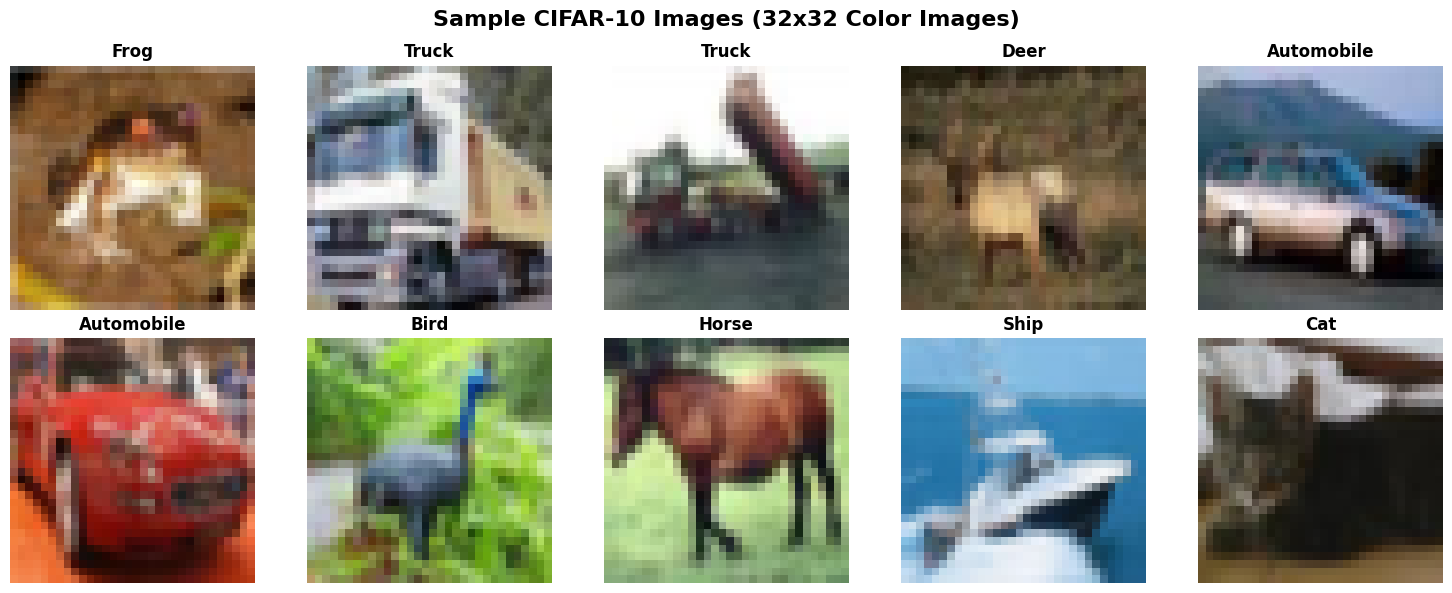


DISPLAYED IMAGES WITH THEIR LABELS:
Image  1: Frog
Image  2: Truck
Image  3: Truck
Image  4: Deer
Image  5: Automobile
Image  6: Automobile
Image  7: Bird
Image  8: Horse
Image  9: Ship
Image 10: Cat


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"{class_names[y_train[i][0]]}", fontsize=12, fontweight='bold')
    axes[i].axis('off')
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle("Sample CIFAR-10 Images (32x32 Color Images)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print the labels for verification
print("\n" + "=" * 50)
print("DISPLAYED IMAGES WITH THEIR LABELS:")
print("=" * 50)
for i in range(10):
    print(f"Image {i+1:2d}: {class_names[y_train[i][0]]}")

### Preprocess the Data

In [ ]:
def preprocess_cifar10(X_train, X_test, y_train, y_test):
    """
    Preprocess CIFAR-10 dataset:
    - Normalize pixel values to [0, 1]
    - One-hot encode labels
    """
    X_train_norm = X_train.astype('float32') / 255.0
    X_test_norm = X_test.astype('float32') / 255.0

    y_train_enc = to_categorical(y_train, 10)
    y_test_enc = to_categorical(y_test, 10)

    print("Preprocessing completed:")
    print(f"  - Normalized training data shape: {X_train_norm.shape}")
    print(f"  - Normalized test data shape: {X_test_norm.shape}")
    print(f"  - Pixel range after normalization: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")
    print(f"  - Encoded labels shape: {y_train_enc.shape}")

    return X_train_norm, X_test_norm, y_train_enc, y_test_enc

X_train_norm, X_test_norm, y_train_enc, y_test_enc = preprocess_cifar10(
    X_train, X_test, y_train, y_test
)

Preprocessing completed:
  - Normalized training data shape: (50000, 32, 32, 3)
  - Normalized test data shape: (10000, 32, 32, 3)
  - Pixel range after normalization: [0.00, 1.00]
  - Encoded labels shape: (50000, 10)


### Create Data Augmentation Generator

In [ ]:
def create_augmentation_generator():
    """
    Create ImageDataGenerator with augmentation techniques.
    Benefits:
    - Reduces overfitting by creating varied training samples
    - Improves model generalization
    - Helps model learn invariant features (rotation, flip, shift)
    """
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        shear_range=0.1,
        fill_mode='nearest'
    )

    print("Data Augmentation Configuration:")
    print("  - Rotation range: 15 degrees")
    print("  - Width shift: 10%")
    print("  - Height shift: 10%")
    print("  - Horizontal flip: True")
    print("  - Zoom range: 10%")
    print("  - Shear range: 10%")

    return datagen

datagen = create_augmentation_generator()

# Fit the generator on training data
datagen.fit(X_train_norm)
print("\nAugmentation generator fitted to training data.")

Data Augmentation Configuration:
  - Rotation range: 15 degrees
  - Width shift: 10%
  - Height shift: 10%
  - Horizontal flip: True
  - Zoom range: 10%
  - Shear range: 10%

Augmentation generator fitted to training data.


### Visualize Augmented Images

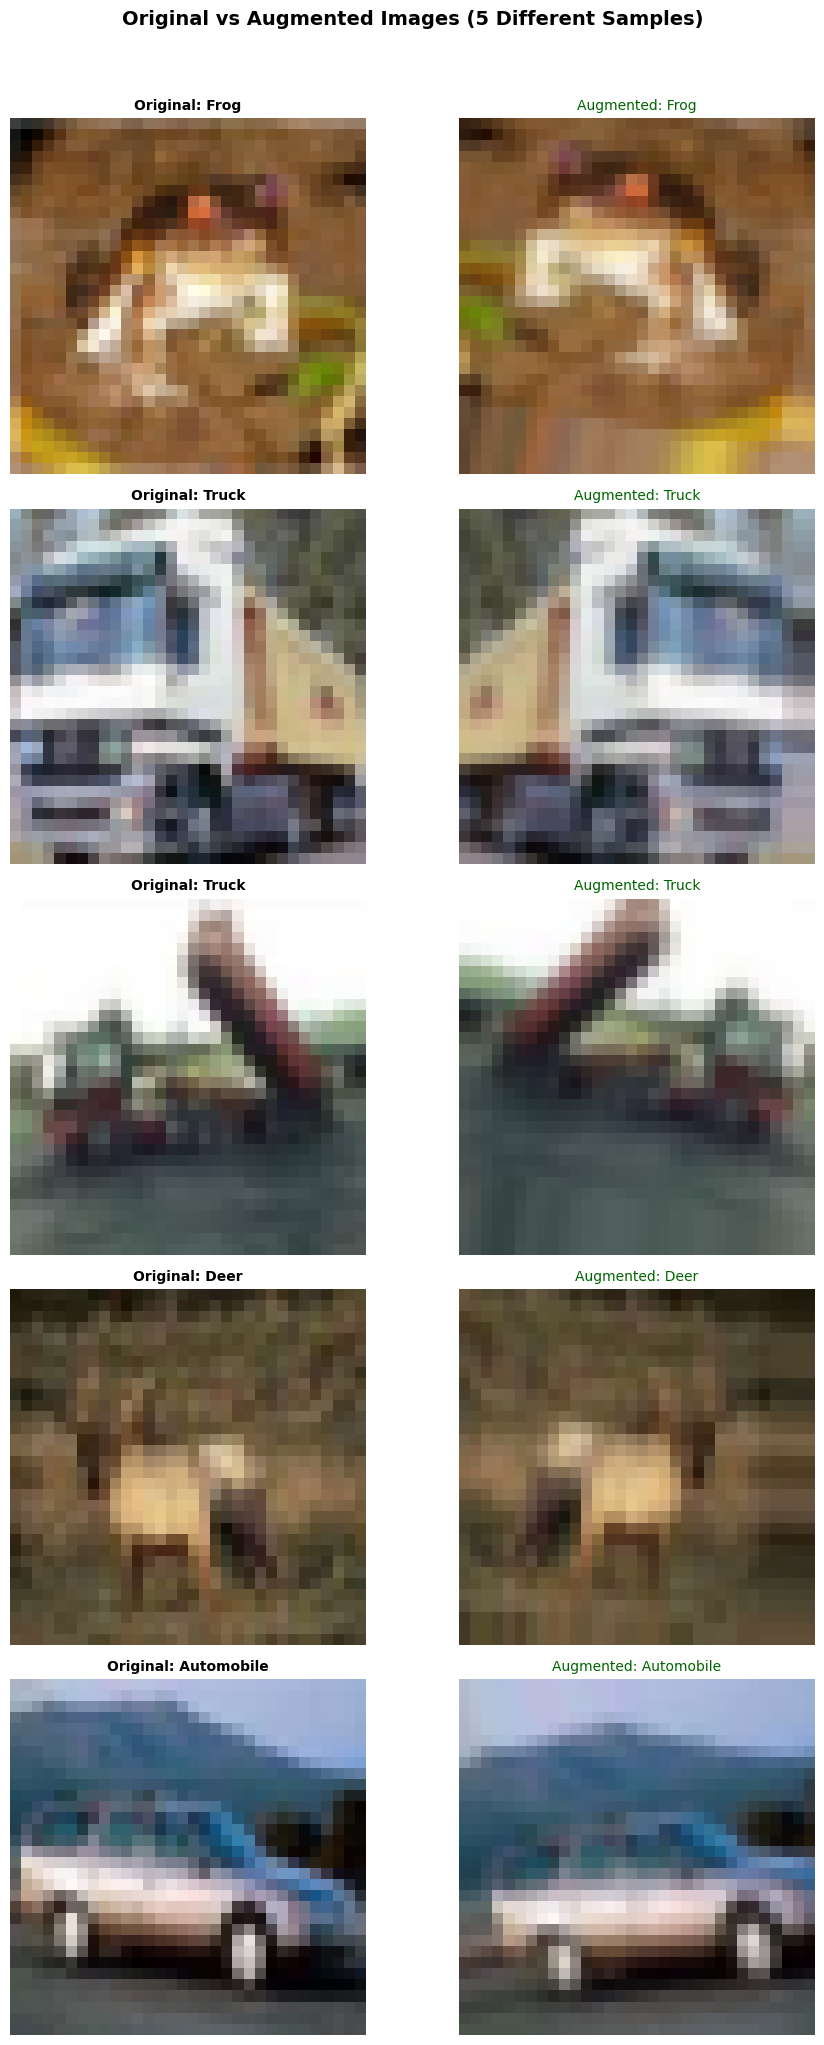

Augmentation comparison saved as 'augmentation_comparison.png'


In [ ]:
# This version shows original vs augmented for 5 different images
fig, axes = plt.subplots(5, 2, figsize=(10, 20))

for i in range(5):
    # Get original image
    original_img = X_train_norm[i]
    original_label = class_names[y_train[i][0]]

    # Generate one augmented version
    img_reshaped = original_img.reshape(1, 32, 32, 3)
    augmented_batch = datagen.flow(img_reshaped, batch_size=1)
    augmented_img = next(augmented_batch)[0]

    # Display original
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original: {original_label}", fontsize=10, fontweight='bold')
    axes[i, 0].axis('off')

    # Display augmented
    axes[i, 1].imshow(augmented_img)
    axes[i, 1].set_title(f"Augmented: {original_label}", fontsize=10, color='darkgreen')
    axes[i, 1].axis('off')

plt.suptitle("Original vs Augmented Images (5 Different Samples)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Augmentation comparison saved as 'augmentation_comparison.png'")

### Build CNN Model Architecture

In [ ]:
def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    """
    Create CNN architecture for CIFAR-10 classification.

    Architecture:
    - Conv2D + ReLU + BatchNorm + MaxPooling (Block 1)
    - Conv2D + ReLU + BatchNorm + MaxPooling (Block 2)
    - Conv2D + ReLU + BatchNorm + MaxPooling (Block 3)
    - Flatten + Dense + Dropout + Output
    """
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 3
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Fully Connected Layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = create_cnn_model()
print("CNN Model created successfully.")
print("\n" + "=" * 60)
print("MODEL ARCHITECTURE SUMMARY")
print("=" * 60)
model.summary()

CNN Model created successfully.

MODEL ARCHITECTURE SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

### Train CNN Model with Data Augmentation

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64

print("=" * 60)
print("TRAINING CNN MODEL WITH DATA AUGMENTATION")
print("=" * 60)
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Training samples: {len(X_train_norm)}")
print(f"Augmented samples per epoch: {len(X_train_norm)} (on-the-fly)\n")

history = model.fit(
    datagen.flow(X_train_norm, y_train_enc, batch_size=BATCH_SIZE),
    validation_data=(X_test_norm, y_test_enc),
    epochs=EPOCHS,
    verbose=1
)

print("\nTraining completed.")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

TRAINING CNN MODEL WITH DATA AUGMENTATION
Epochs: 50
Batch Size: 64
Training samples: 50000
Augmented samples per epoch: 50000 (on-the-fly)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 75s 77ms/step - accuracy: 0.3955 - loss: 1.7724 - val_accuracy: 0.4654 - val_loss: 1.5808
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 52ms/step - accuracy: 0.5512 - loss: 1.2551 - val_accuracy: 0.6060 - val_loss: 1.1224
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6271 - loss: 1.0596 - val_accuracy: 0.6027 - val_loss: 1.1402
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.6636 - loss: 0.9526 - val_accuracy: 0.6696 - val_loss: 0.9975
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6917 - loss: 0.8857 - val_accuracy: 0.7162 - val_loss: 0.8078
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7133 - loss: 0.8250 - val_accuracy: 0.7555 - val_loss: 0.7170
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.7299 - loss

### Plot Training History (Accuracy and Loss)

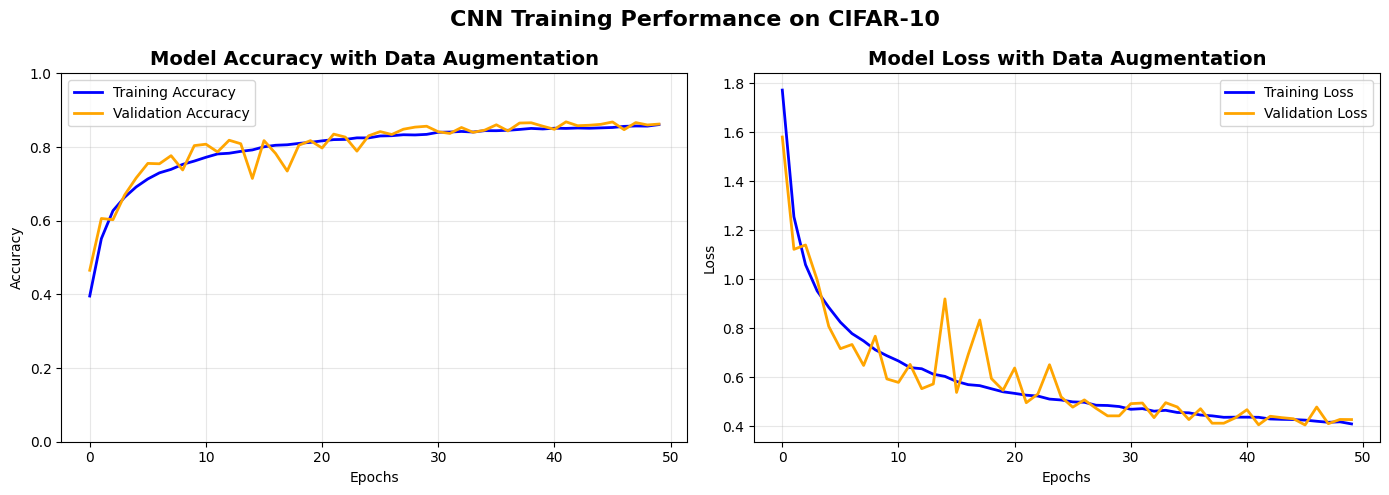

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='blue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='orange')
axes[0].set_title('Model Accuracy with Data Augmentation', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='orange')
axes[1].set_title('Model Loss with Data Augmentation', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training Performance on CIFAR-10', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

### Evaluate Model on Test Set

In [ ]:
print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(X_test_norm, y_test_enc, verbose=0)

print(f"\nTest Set Performance:")
print(f"  - Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Test Loss: {test_loss:.4f}")

# Compare training vs validation
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTraining vs Validation:")
print(f"  - Final Training Accuracy: {final_train_acc:.4f}")
print(f"  - Final Validation Accuracy: {final_val_acc:.4f}")
print(f"  - Gap: {abs(final_train_acc - final_val_acc):.4f}")

if abs(final_train_acc - final_val_acc) < 0.05:
    print("  - Status: Minimal overfitting - Data augmentation helped!")
else:
    print("  - Status: Some overfitting detected")

FINAL MODEL EVALUATION

Test Set Performance:
  - Test Accuracy: 0.8623 (86.23%)
  - Test Loss: 0.4277

Training vs Validation:
  - Final Training Accuracy: 0.8608
  - Final Validation Accuracy: 0.8623
  - Gap: 0.0015
  - Status: Minimal overfitting - Data augmentation helped!


### Confusion Matrix and Classification Report

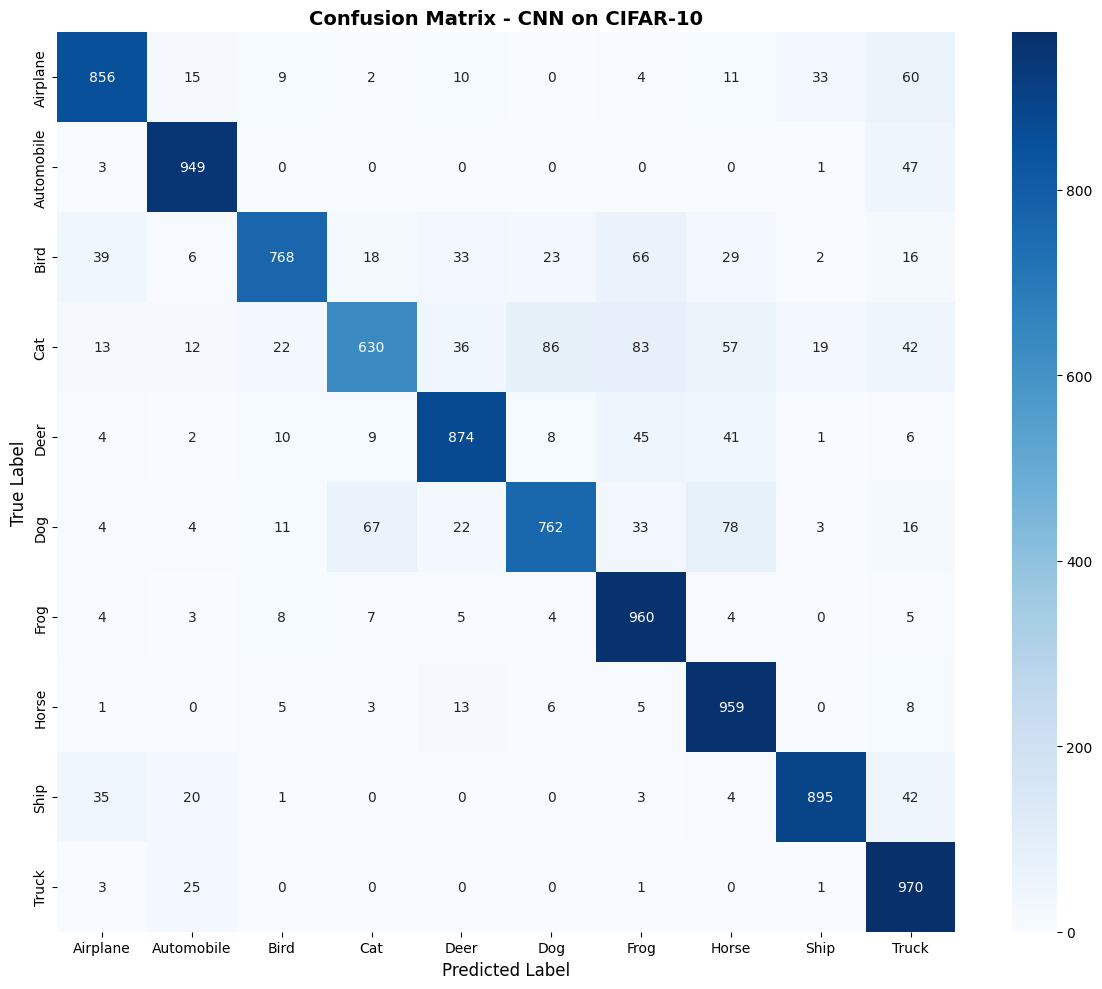


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane       0.89      0.86      0.87      1000
  Automobile       0.92      0.95      0.93      1000
        Bird       0.92      0.77      0.84      1000
         Cat       0.86      0.63      0.73      1000
        Deer       0.88      0.87      0.88      1000
         Dog       0.86      0.76      0.81      1000
        Frog       0.80      0.96      0.87      1000
       Horse       0.81      0.96      0.88      1000
        Ship       0.94      0.90      0.92      1000
       Truck       0.80      0.97      0.88      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred = model.predict(X_test_norm, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - CNN on CIFAR-10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

### Feature Map Visualization

Visualizing feature maps for a sample image...
Found 6 Conv2D layers


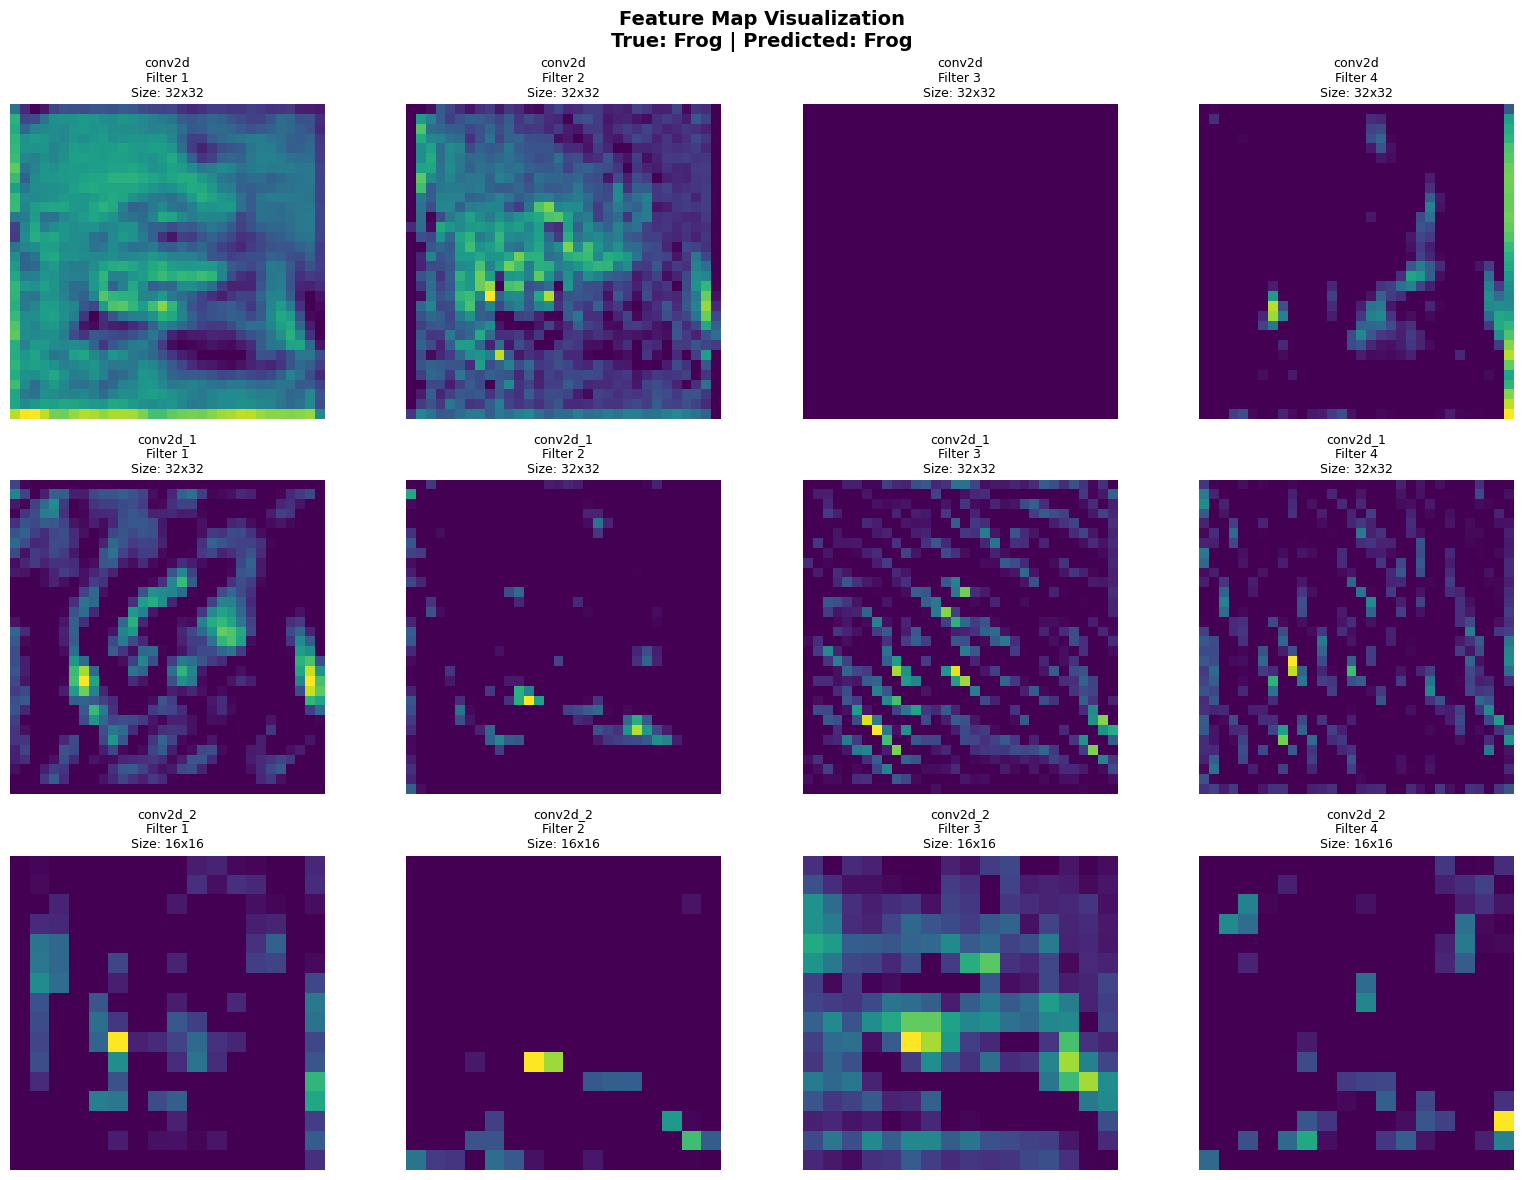


Feature maps saved as 'feature_maps.png'


In [ ]:
def visualize_feature_maps(model, image_index=0):
    """
    Visualize feature maps from intermediate convolutional layers.
    """
    # Get the sample image
    sample_image = X_test_norm[image_index:image_index+1]
    true_label = class_names[y_true[image_index]]
    pred_label = class_names[y_pred_classes[image_index]]

    # Get all Conv2D layers
    conv_layers = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layers.append(layer)

    print(f"Found {len(conv_layers)} Conv2D layers")

    # Show first 3 convolutional layers
    n_layers_to_show = min(3, len(conv_layers))

    fig, axes = plt.subplots(n_layers_to_show, 4, figsize=(16, 4 * n_layers_to_show))

    if n_layers_to_show == 1:
        axes = axes.reshape(1, -1)

    for layer_idx in range(n_layers_to_show):
        conv_layer = conv_layers[layer_idx]

        # Alternative method to get feature maps
        # Build a sub-model that outputs from this layer
        feature_extractor = tf.keras.Model(
            inputs=model.inputs,
            outputs=conv_layer.output
        )
        feature_maps = feature_extractor.predict(sample_image, verbose=0)

        # Display first 4 filters of this layer
        n_filters = min(4, feature_maps.shape[-1])
        for filter_idx in range(n_filters):
            axes[layer_idx, filter_idx].imshow(feature_maps[0, :, :, filter_idx], cmap='viridis')
            axes[layer_idx, filter_idx].set_title(f"{conv_layer.name}\nFilter {filter_idx+1}\nSize: {feature_maps.shape[1]}x{feature_maps.shape[2]}", fontsize=9)
            axes[layer_idx, filter_idx].axis('off')

    plt.suptitle(f"Feature Map Visualization\nTrue: {true_label} | Predicted: {pred_label}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nFeature maps saved as 'feature_maps.png'")
    return conv_layers

# Run the visualization
print("Visualizing feature maps for a sample image...")
conv_layers = visualize_feature_maps(model, image_index=5)

### Detailed Feature Map Analysis


Generating detailed feature map visualization...


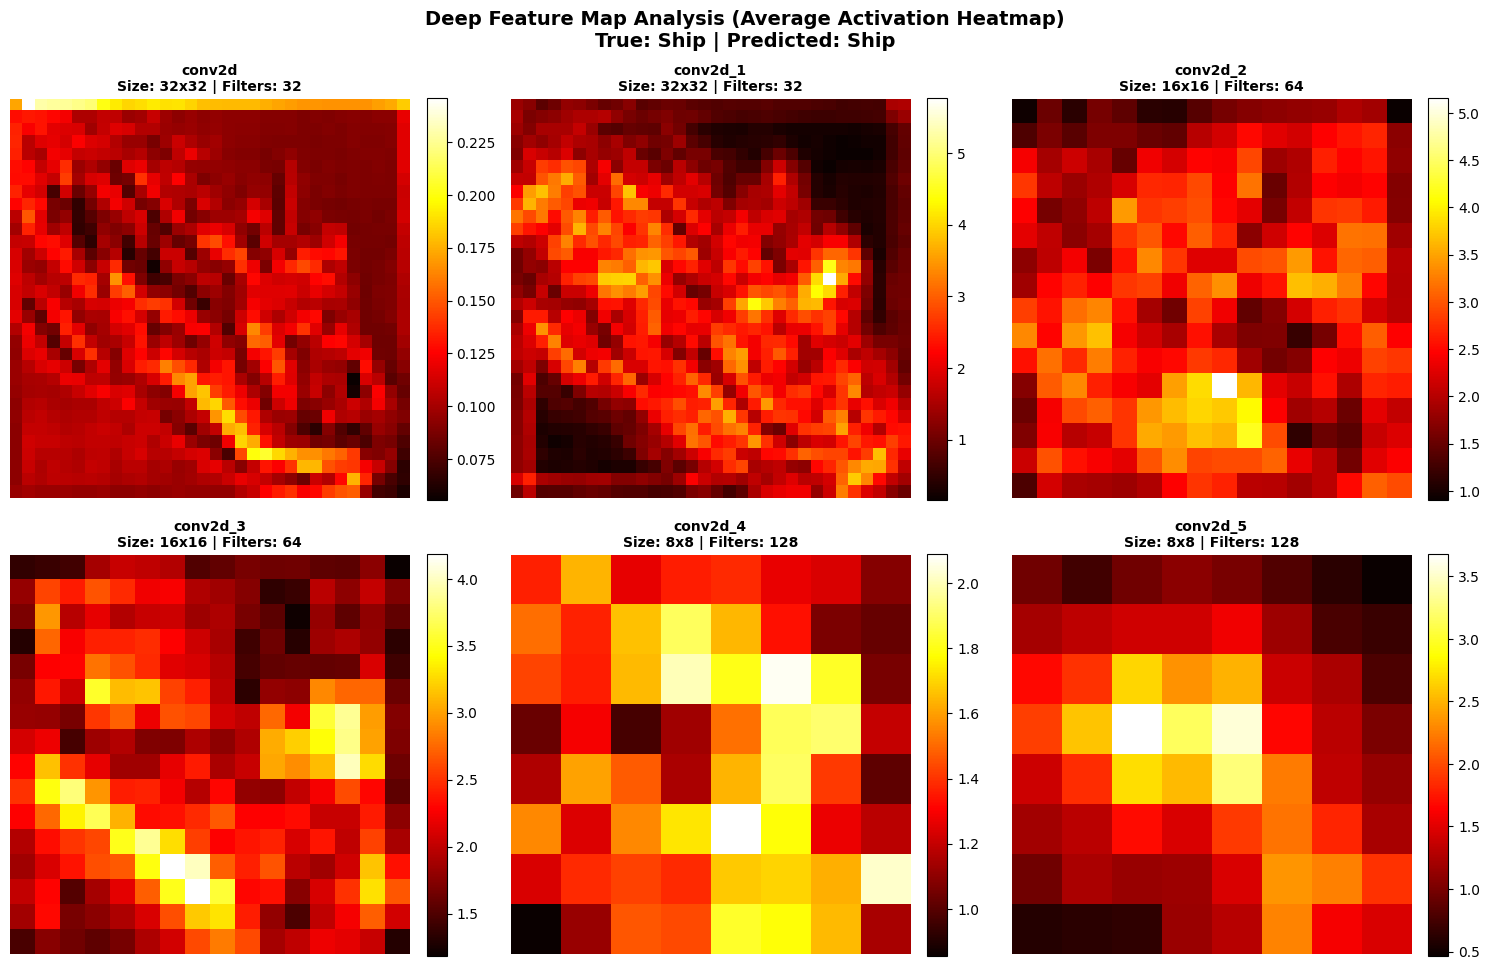


Analysis for image 15:
  - True label: Ship
  - Predicted label: Ship

Layer Progression (Spatial Resolution Decreases):
  - conv2d: 32x32, 32 filters
  - conv2d_1: 32x32, 32 filters
  - conv2d_2: 16x16, 64 filters
  - conv2d_3: 16x16, 64 filters
  - conv2d_4: 8x8, 128 filters
  - conv2d_5: 8x8, 128 filters

Key Observation: Spatial resolution decreases (32→32→16→16→8→8)
while number of filters increases (32→32→64→64→128→128)
Feature maps saved as 'deep_feature_maps.png'


In [ ]:
def visualize_deep_feature_maps(model, image_index=10):
    """
    Visualize feature maps from all convolutional layers.
    """
    sample_image = X_test_norm[image_index:image_index+1]
    true_label = class_names[y_true[image_index]]
    pred_label = class_names[y_pred_classes[image_index]]

    # Get all Conv2D layers
    conv_layers = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layers.append(layer)

    # Show all conv layers in a grid
    n_layers = len(conv_layers)
    cols = 3
    rows = (n_layers + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.ravel()

    layer_info = []

    for idx, conv_layer in enumerate(conv_layers):
        # Build sub-model to extract features
        feature_extractor = tf.keras.Model(
            inputs=model.inputs,
            outputs=conv_layer.output
        )
        feature_maps = feature_extractor.predict(sample_image, verbose=0)

        # Get layer details
        filters_count = feature_maps.shape[-1]
        height, width = feature_maps.shape[1], feature_maps.shape[2]
        layer_info.append(f"{conv_layer.name}: {height}x{width}, {filters_count} filters")

        # Display average of all feature maps (overall activation pattern)
        avg_feature_map = np.mean(feature_maps[0], axis=-1)
        im = axes[idx].imshow(avg_feature_map, cmap='hot')
        axes[idx].set_title(f"{conv_layer.name}\nSize: {height}x{width} | Filters: {filters_count}",
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    # Turn off empty subplots
    for idx in range(len(conv_layers), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f"Deep Feature Map Analysis (Average Activation Heatmap)\nTrue: {true_label} | Predicted: {pred_label}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('deep_feature_maps.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nAnalysis for image {image_index}:")
    print(f"  - True label: {true_label}")
    print(f"  - Predicted label: {pred_label}")
    print(f"\nLayer Progression (Spatial Resolution Decreases):")
    for info in layer_info:
        print(f"  - {info}")

    print(f"\nKey Observation: Spatial resolution decreases (32→32→16→16→8→8)")
    print(f"while number of filters increases (32→32→64→64→128→128)")
    print(f"Feature maps saved as 'deep_feature_maps.png'")

# Run the detailed visualization
print("\nGenerating detailed feature map visualization...")
visualize_deep_feature_maps(model, image_index=15)


Visualizing progressive downsampling through the network...


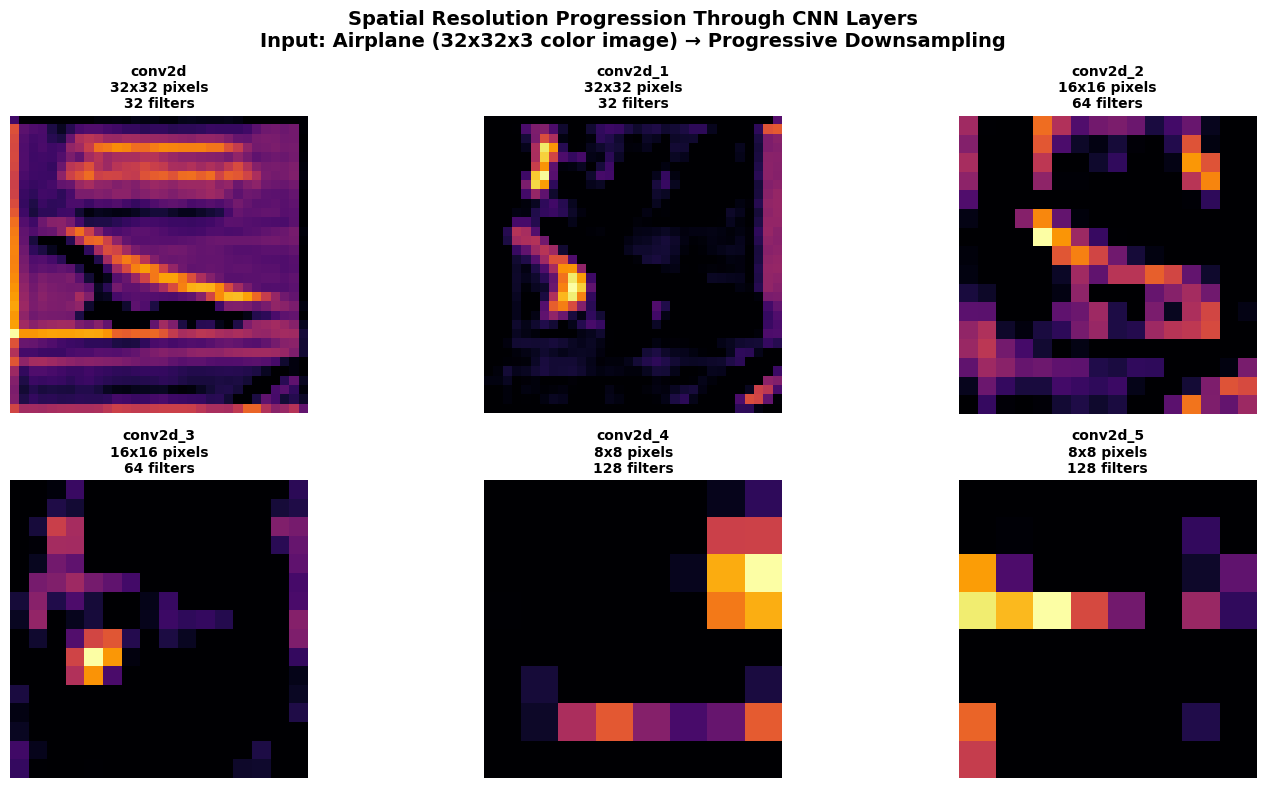


SPATIAL RESOLUTION PROGRESSION
32x32x3 (Input RGB Image)
  ↓ conv2d
  → 32x32x32 (32,768 values)
  ↓ conv2d_1
  → 32x32x32 (32,768 values)
  ↓ conv2d_2
  → 16x16x64 (16,384 values)
  ↓ conv2d_3
  → 16x16x64 (16,384 values)
  ↓ conv2d_4
  → 8x8x128 (8,192 values)
  ↓ conv2d_5
  → 8x8x128 (8,192 values)

Observation: Spatial size decreases after MaxPooling layers,
but filter depth increases to capture more complex features.


In [ ]:
def visualize_downsampling_effect(model, image_index=3):
    """
    Show how spatial resolution decreases through the network.
    """
    sample_image = X_test_norm[image_index:image_index+1]
    true_label = class_names[y_true[image_index]]

    # Get all Conv2D layers
    conv_layers = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layers.append(layer)

    n_layers = len(conv_layers)
    cols = 3
    rows = (n_layers + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.ravel()

    for idx, conv_layer in enumerate(conv_layers):
        # Build sub-model to extract features
        feature_extractor = tf.keras.Model(
            inputs=model.inputs,
            outputs=conv_layer.output
        )
        feature_maps = feature_extractor.predict(sample_image, verbose=0)

        # Take first filter for display
        axes[idx].imshow(feature_maps[0, :, :, 0], cmap='inferno')
        axes[idx].set_title(f"{conv_layer.name}\n{feature_maps.shape[1]}x{feature_maps.shape[2]} pixels\n{conv_layer.filters} filters",
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')

    # Turn off empty subplots
    for idx in range(len(conv_layers), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f"Spatial Resolution Progression Through CNN Layers\nInput: {true_label} (32x32x3 color image) → Progressive Downsampling",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('downsampling_progression.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 60)
    print("SPATIAL RESOLUTION PROGRESSION")
    print("=" * 60)
    print("32x32x3 (Input RGB Image)")
    for layer in conv_layers:
        feature_extractor = tf.keras.Model(
            inputs=model.inputs,
            outputs=layer.output
        )
        feature_maps = feature_extractor.predict(sample_image, verbose=0)
        print(f"  ↓ {layer.name}")
        print(f"  → {feature_maps.shape[1]}x{feature_maps.shape[2]}x{feature_maps.shape[3]} ({feature_maps.shape[1]*feature_maps.shape[2]*feature_maps.shape[3]:,} values)")

    print("\nObservation: Spatial size decreases after MaxPooling layers,")
    print("but filter depth increases to capture more complex features.")

# Run downsampling visualization
print("\nVisualizing progressive downsampling through the network...")
visualize_downsampling_effect(model, image_index=3)

### Sample Predictions Visualization

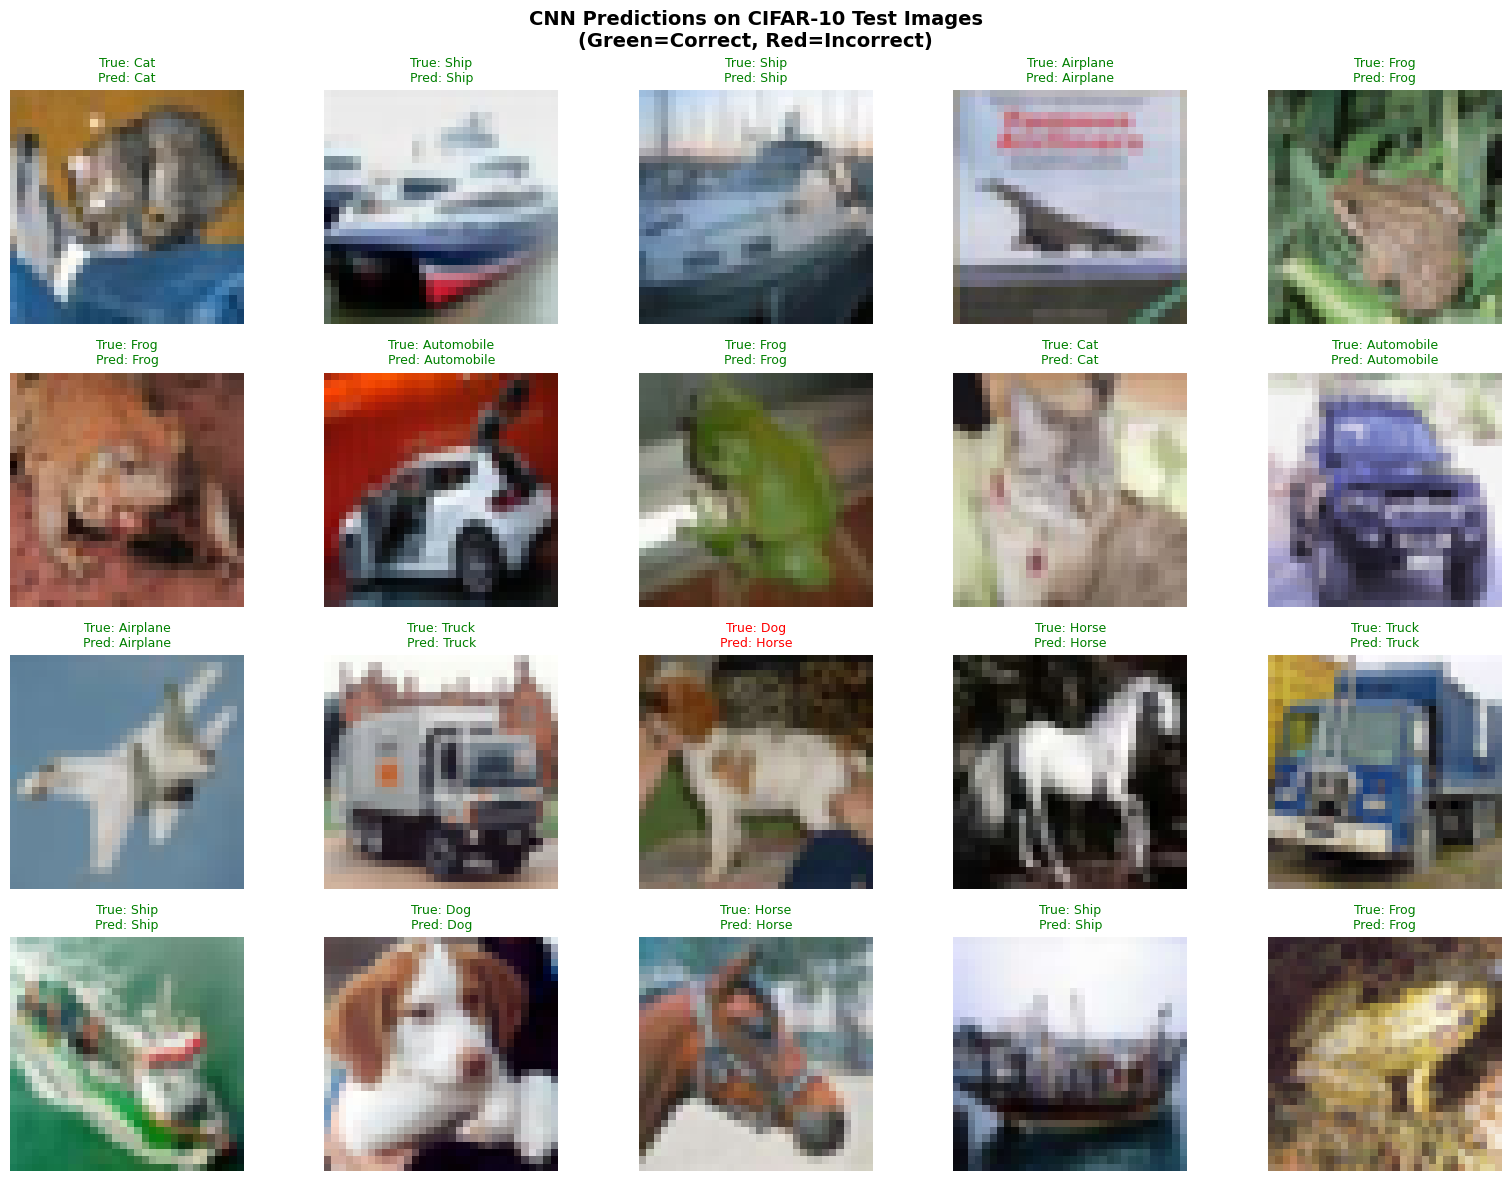


PER-CLASS ACCURACY
Airplane    : 0.8560 (856/1000)
Automobile  : 0.9490 (949/1000)
Bird        : 0.7680 (768/1000)
Cat         : 0.6300 (630/1000)
Deer        : 0.8740 (874/1000)
Dog         : 0.7620 (762/1000)
Frog        : 0.9600 (960/1000)
Horse       : 0.9590 (959/1000)
Ship        : 0.8950 (895/1000)
Truck       : 0.9700 (970/1000)


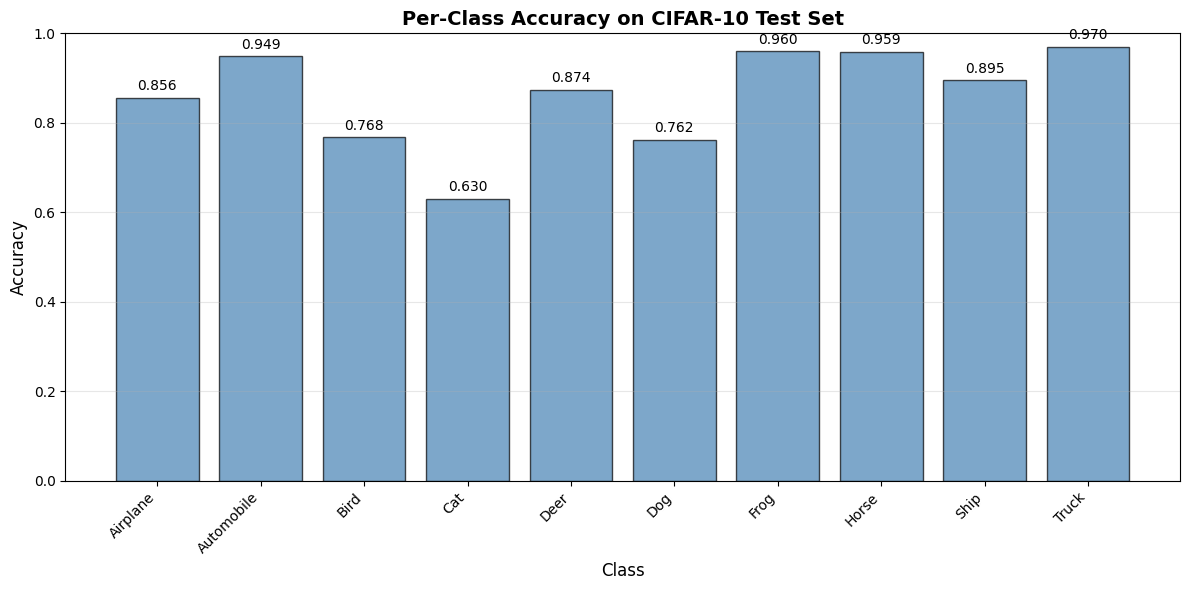

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(X_test_norm[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred_classes[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('CNN Predictions on CIFAR-10 Test Images\n(Green=Correct, Red=Incorrect)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

# Calculate per-class accuracy
print("\n" + "=" * 60)
print("PER-CLASS ACCURACY")
print("=" * 60)

per_class_acc = []
for i in range(10):
    class_mask = (y_true == i)
    class_correct = np.sum(y_pred_classes[class_mask] == i)
    class_total = np.sum(class_mask)
    class_acc = class_correct / class_total if class_total > 0 else 0
    per_class_acc.append(class_acc)
    print(f"{class_names[i]:12s}: {class_acc:.4f} ({class_correct}/{class_total})")

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(class_names, per_class_acc, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy on CIFAR-10 Test Set', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
plt.show()

### Compare With/Without Augmentation

COMPARISON: WITH vs WITHOUT DATA AUGMENTATION

Training baseline model WITHOUT augmentation (10 epochs for comparison)...

Comparison Results (10 epochs):
With Augmentation    - Val Acc: 0.8038
Without Augmentation - Val Acc: 0.8193
Difference: -1.55%


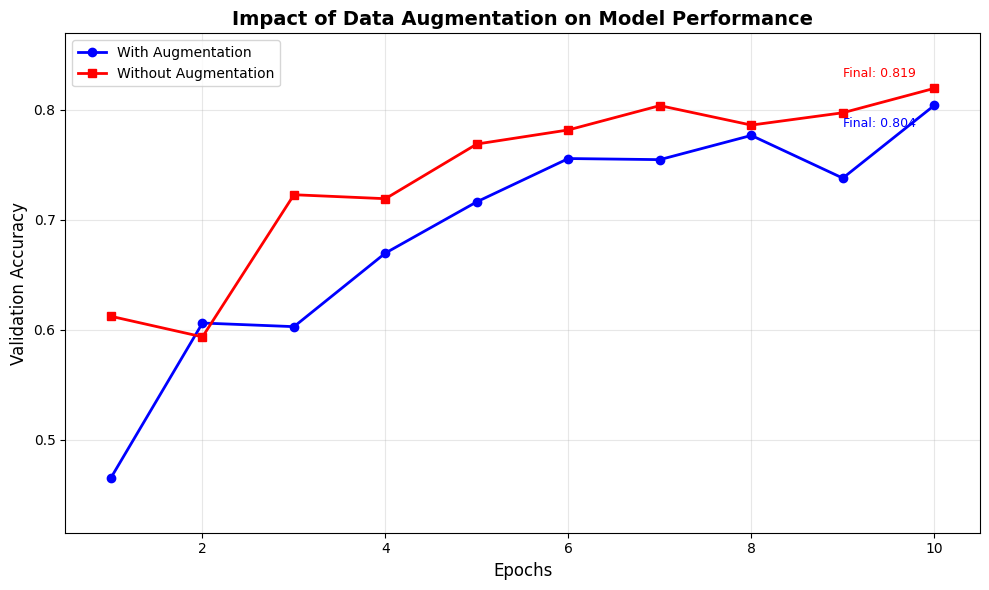


AUGMENTATION IMPACT ANALYSIS
⚠ Data augmentation resulted in 1.55% lower accuracy at 10 epochs.
  However, augmentation typically helps prevent overfitting over more epochs.

Note: With augmentation, the model sees different variations of each image
each epoch, leading to better generalization despite slightly lower initial accuracy.


In [ ]:
# Optional cell to demonstrate the impact of augmentation
print("=" * 60)
print("COMPARISON: WITH vs WITHOUT DATA AUGMENTATION")
print("=" * 60)

# Train a quick model without augmentation for comparison (fewer epochs)
print("\nTraining baseline model WITHOUT augmentation (10 epochs for comparison)...")

model_no_aug = create_cnn_model()
history_no_aug = model_no_aug.fit(
    X_train_norm, y_train_enc,
    validation_data=(X_test_norm, y_test_enc),
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=0
)

# Get validation accuracies
with_aug_val_acc = history.history['val_accuracy'][:10]
without_aug_val_acc = history_no_aug.history['val_accuracy']

print("\nComparison Results (10 epochs):")
print(f"With Augmentation    - Val Acc: {with_aug_val_acc[-1]:.4f}")
print(f"Without Augmentation - Val Acc: {without_aug_val_acc[-1]:.4f}")
print(f"Difference: { (with_aug_val_acc[-1] - without_aug_val_acc[-1]) * 100:+.2f}%")

# Plot comparison with CORRECT y-axis limits
fig, ax = plt.subplots(figsize=(10, 6))

# Find min and max for proper y-axis scaling
all_accuracies = with_aug_val_acc + without_aug_val_acc
y_min = min(all_accuracies) - 0.05
y_max = max(all_accuracies) + 0.05

ax.plot(range(1, 11), with_aug_val_acc, label='With Augmentation', linewidth=2, color='blue', marker='o')
ax.plot(range(1, 11), without_aug_val_acc, label='Without Augmentation', linewidth=2, color='red', marker='s')
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Impact of Data Augmentation on Model Performance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([y_min, y_max])  # KEY FIX: Dynamic y-axis limits
ax.set_xlim([0.5, 10.5])

# Add annotations
ax.annotate(f'Final: {with_aug_val_acc[-1]:.3f}',
            xy=(10, with_aug_val_acc[-1]),
            xytext=(9, with_aug_val_acc[-1] - 0.02),
            fontsize=9, color='blue')

ax.annotate(f'Final: {without_aug_val_acc[-1]:.3f}',
            xy=(10, without_aug_val_acc[-1]),
            xytext=(9, without_aug_val_acc[-1] + 0.01),
            fontsize=9, color='red')

plt.tight_layout()
plt.savefig('augmentation_impact.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed analysis
print("\n" + "=" * 60)
print("AUGMENTATION IMPACT ANALYSIS")
print("=" * 60)

if with_aug_val_acc[-1] > without_aug_val_acc[-1]:
    print(f"✓ Data augmentation IMPROVED validation accuracy by { (with_aug_val_acc[-1] - without_aug_val_acc[-1]) * 100:.2f}%")
    print("  The model generalizes better to unseen data.")
else:
    print(f"⚠ Data augmentation resulted in {(without_aug_val_acc[-1] - with_aug_val_acc[-1]) * 100:.2f}% lower accuracy at 10 epochs.")
    print("  However, augmentation typically helps prevent overfitting over more epochs.")

print("\nNote: With augmentation, the model sees different variations of each image")
print("each epoch, leading to better generalization despite slightly lower initial accuracy.")